In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../../..")

from gob.benchmarks import *
from gob.optimizers import *
import matplotlib
matplotlib.rcParams.update({"text.usetex": True})

In [2]:
class MinWrapper:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.values = []
  
  def __call__(self, x):
    y = self.func(x)
    self.values.append(y)
    return y
  
  def get_min_per_iteration(self, n_particles):
    mins = []
    for i in range(len(self.values) // n_particles):
      prev_min = mins[-1] if mins else float("inf")
      actual_min = np.min(self.values[i * n_particles : (i + 1) * n_particles])
      mins.append(min(prev_min, actual_min))
    return mins

class MinWrapperGrad:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.values = []
    self.prev_sample = None
  
  def __call__(self, x):
    y = self.func(x)
    if self.prev_sample is None or not np.all(np.abs(x - self.prev_sample) <= 2e-9):
      self.values.append(y)
    self.prev_sample = x
    return y
  
  def get_min_per_iteration(self, n_particles):
    mins = []
    for i in range(len(self.values) // n_particles):
      prev_min = mins[-1] if mins else float("inf")
      actual_min = np.min(self.values[i * n_particles : (i + 1) * n_particles])
      mins.append(min(prev_min, actual_min))
    return mins

In [3]:
def format_results(res):
  for i in range(len(res)):
    if len(res[i]) < iter:
      print(f"Run {i} of mins has length {len(res[i])} instead of {iter}")
      # Copy the last value to extend the length
      last_value = res[i][-1]
      res[i] = list(res[i]) + [last_value] * (iter - len(res[i]))

In [4]:
g = Levy()
dim = 10
bounds = augment_dimensions(g.visual_bounds, dim)
iter = 500
verbose = False
n_runs = 5
independent_noise = True
wrapper = MinWrapper
alg = CBO
cn_alg = lambda moment: SMD_CBO(bounds=bounds, n_particles=100, iter=iter, moment=moment, verbose=verbose)

In [5]:
mins_10 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=10, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_10.append(f.get_min_per_iteration(10)[:iter])

format_results(mins_10)
mins_10 = np.array(mins_10)

Results for CBO on Levy: 95.37960120919782
Results for CBO on Levy: 99.52700887102498
Results for CBO on Levy: 10.841391425367021
Results for CBO on Levy: 70.54400045885771
Results for CBO on Levy: 74.56835367732226


In [6]:
mins_100 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=100, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_100.append(f.get_min_per_iteration(100)[:iter])

format_results(mins_100)
mins_100 = np.array(mins_100)

Results for CBO on Levy: 40.20169328445458
Results for CBO on Levy: 34.69636429391505
Results for CBO on Levy: 35.03463990633419
Results for CBO on Levy: 22.467875100630874
Results for CBO on Levy: 40.144679621755415


In [7]:
mins_1000 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=1000, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_1000.append(f.get_min_per_iteration(1000)[:iter])

format_results(mins_1000)
mins_1000 = np.array(mins_1000)

Results for CBO on Levy: 16.164493147684933
Results for CBO on Levy: 22.5356943826095
Results for CBO on Levy: 16.34869459682081
Results for CBO on Levy: 17.938253242806656
Results for CBO on Levy: 23.918342075395756


In [8]:
mins_5000 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=5000, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_5000.append(f.get_min_per_iteration(5000)[:iter])

format_results(mins_5000)
mins_5000 = np.array(mins_5000)

Results for CBO on Levy: 17.972717396140986
Results for CBO on Levy: 13.100489347625349
Results for CBO on Levy: 17.06650233898265
Results for CBO on Levy: 15.141718163153568
Results for CBO on Levy: 11.565400680160854


In [9]:
mins_mvar = []
for i in range(n_runs):
  f = wrapper(g)

  opt = cn_alg("MVAR")
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_mvar.append(f.get_min_per_iteration(100)[:iter])

format_results(mins_mvar)
mins_mvar = np.array(mins_mvar)

Results for SMD-CBO on Levy: 21.275441264931548
Results for SMD-CBO on Levy: 20.522803076717206
Results for SMD-CBO on Levy: 16.871847911801034
Results for SMD-CBO on Levy: 24.614225647248766
Results for SMD-CBO on Levy: 13.25881782770913


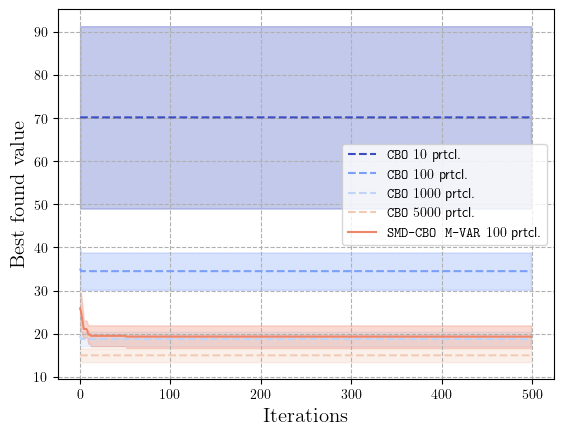

In [20]:
alg_name = "CBO"
cn_alg_name = "SMD-CBO"

latex_label = lambda s: r"\texttt{" + s.replace("_", r"\_") + "}"

cmap = matplotlib.colormaps["coolwarm"]

c0 = cmap(0)
c1 = cmap(0.2)
c2 = cmap(0.4)
c3 = cmap(0.6)
c4 = cmap(0.8)

fig, ax = plt.subplots()

coeff = 1.5

mean = mins_10.mean(axis=0)
std = mins_10.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $10$ prtcl.", linestyle="--", color=c0)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c0)

mean = mins_100.mean(axis=0)
std = mins_100.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $100$ prtcl.", linestyle="--", color=c1)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c1)

mean = mins_1000.mean(axis=0)
std = mins_1000.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $1000$ prtcl.", linestyle="--", color=c2)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c2)

mean = mins_5000.mean(axis=0)
std = mins_5000.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $5000$ prtcl.", linestyle="--", color=c3)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c3)

mean = mins_mvar.mean(axis=0)
std = mins_mvar.std(axis=0)
ax.plot(mean, label=latex_label(f"{cn_alg_name} M-VAR") + " $100$ prtcl.", linestyle="-", c=c4)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c4)

ax.set_xlabel(r"$\textrm{Iterations}$", fontsize=15)
ax.set_ylabel(r"$\textrm{Best found value}$", fontsize=15)
ax.grid(linestyle="--")
ax.legend()

#plt.yscale("log")

in_status = "IN" if independent_noise else "no_IN"
plt.savefig(f"impact_noise_{alg_name.lower()}_{in_status}_{g}.pdf")

In [19]:
cmap(0)

(np.float64(0.2298057),
 np.float64(0.298717966),
 np.float64(0.753683153),
 np.float64(1.0))

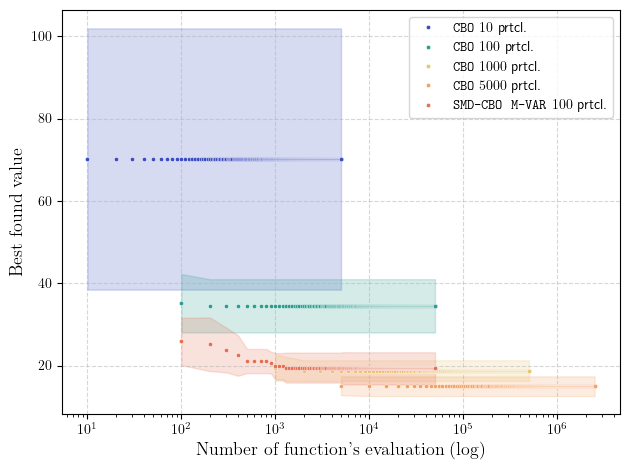

In [30]:
import numpy as np

alg_name = "CBO"
cn_alg_name = "SMD-CBO"

latex_label = lambda s: r"\texttt{" + s.replace("_", r"\_") + "}"

# Palette plus contrastée que 5 nuances de coolwarm rapprochées
colors = ["#3b4cc0", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

fig, ax = plt.subplots()

def plot_series(mins, step, color, label):
    mean = mins.mean(axis=0)
    std = mins.std(axis=0)          # écart-type, même unité que mean
    xs = np.array([i * step for i in range(1, iter + 1)])

    ax.plot(xs, mean, 'o', markersize=3, color=color, label=label,
             zorder=3, markeredgecolor='white', markeredgewidth=0.3)
    ax.fill_between(xs, mean - std, mean + std, color=color, alpha=0.2, zorder=1)

plot_series(mins_10,   10,   colors[0], latex_label(alg_name) + r" $10$ prtcl.")
plot_series(mins_100,  100,  colors[1], latex_label(alg_name) + r" $100$ prtcl.")
plot_series(mins_1000, 1000, colors[2], latex_label(alg_name) + r" $1000$ prtcl.")
plot_series(mins_5000, 5000, colors[3], latex_label(alg_name) + r" $5000$ prtcl.")
plot_series(mins_mvar, 100,  colors[4], latex_label(f"{cn_alg_name} M-VAR") + r" $100$ prtcl.")

ax.set_xlabel(r"$\textrm{Number of function's evaluation } (\log)$", fontsize=13)
ax.set_ylabel(r"$\textrm{Best found value}$", fontsize=13)
ax.set_xscale("log")

ax.grid(linestyle="--", alpha=0.5)
ax.legend()

fig.tight_layout()
plt.savefig(f"budget_{alg_name.lower()}_{g}.png", bbox_inches="tight")